# CL1/CL3 Spot-Size Physics Fit (Intermediate-Style)

This notebook mirrors the structure of `intermediate_lens_model.ipynb` for a TEM condenser spot-size workflow:

- Fixed downstream optics: `CLmini`, `OPL`
- Optical constraints: hard `B(S->F_OPL)=0`
- Spot proxy: `|A(S->F_OPL)|`
- One scalar root solve per spot target (solve in `f_CL3`)
- Physics bounds enforced in current and ampere-turn space

No JSON export is performed in this version.


In [11]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.constants import c, e, m_e, mu_0
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception:
    pd = None
    HAS_PANDAS = False

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

print(f'Pandas available: {HAS_PANDAS}')


Pandas available: True


## Config

The geometry and electrical constants follow the same style as the intermediate-lens notebook.


In [12]:
# -----------------------------
# Geometry (meters)
# -----------------------------
geometry = {
    'd_S_C1': 0.2,
    'd_C1_C3': 0.04,
    'd_C3_A': 10.0e-3,
    'd_A_Cmini': 25.0e-3,
    'd_Cmini_OPL': 20.0e-3,
    'f_Cmini': 10.0e-3,
    'f_OPL': 10.0e-3,
}

# -----------------------------
# Lens electrical / physical constants
# -----------------------------
I_fs_A = 2.0
U_accel_V = 200e3

turns = {
    'CL1': 3000,
    'CL3': 1800,
}

Gc_phys = {
    'CL1': 8.0e-6,
    'CL3': 4.0e-6,
}

# hard moderate bounds in normalized drive current
I_norm_bounds = {
    'CL1': (0.20, 0.95),
    'CL3': (0.15, 0.80),
}

# -----------------------------
# Spot ladder and solver controls
# -----------------------------
N_spots = 8
A_trim_quantiles = (0.20, 0.95)

# broad solver domain (meters), intersected with physics-derived focal windows
f_solver_bounds = {
    'CL1': (0.8e-3, 120.0e-3),
    'CL3': (0.8e-3, 900.0e-3),
}

f3_scan_points = 12000
B_tolerance = 1e-8
A_rel_tolerance = 1e-6


In [13]:
def compute_Rc_from_voltage(U_accel_V: float) -> float:
    # Rotation constant Rc [rad/AT] from accelerating voltage [V]
    gamma_rel = 1.0 + (e * U_accel_V) / (m_e * c**2)
    v = c * np.sqrt(1.0 - 1.0 / gamma_rel**2)
    return float(e * mu_0 / (2.0 * m_e * v))

Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

Gc_eff = {
    k: Gc_phys[k] * (turns[k] * I_fs_A) ** 2
    for k in ('CL1', 'CL3')
}

AT_bounds = {
    k: (
        turns[k] * I_fs_A * I_norm_bounds[k][0],
        turns[k] * I_fs_A * I_norm_bounds[k][1],
    )
    for k in ('CL1', 'CL3')
}

def focal_bounds_from_current_bounds(gc_eff, i_min, i_max):
    # I = sqrt(1/(Gc_eff * f)) -> f = 1/(Gc_eff * I^2)
    f_min = 1.0 / (gc_eff * i_max**2)
    f_max = 1.0 / (gc_eff * i_min**2)
    return float(f_min), float(f_max)

f_phys_bounds = {
    k: focal_bounds_from_current_bounds(Gc_eff[k], *I_norm_bounds[k])
    for k in ('CL1', 'CL3')
}

f_bounds = {
    k: (
        max(f_solver_bounds[k][0], f_phys_bounds[k][0]),
        min(f_solver_bounds[k][1], f_phys_bounds[k][1]),
    )
    for k in ('CL1', 'CL3')
}

print('Geometry [mm]:')
for k, v in geometry.items():
    print(f'  {k:15s} = {v*1e3:10.4f}')

print()
print(f'Voltage: {U_accel_V/1e3:.1f} kV')
print(f'Rc_phys: {Rc_phys:.6e} rad/AT')
print('turns:', turns)
print('Gc_phys [1/(AT^2*m)]:', {k: f'{v:.3e}' for k, v in Gc_phys.items()})
print('Gc_eff [1/m]:', {k: round(v, 6) for k, v in Gc_eff.items()})

print('\nCurrent bounds [I_norm]:', I_norm_bounds)
print('AT bounds [AT]:', {k: tuple(round(x, 3) for x in v) for k, v in AT_bounds.items()})
print('Physics-derived focal bounds [mm]:', {k: (round(v[0]*1e3, 6), round(v[1]*1e3, 6)) for k, v in f_phys_bounds.items()})
print('Final focal bounds [mm]:', {k: (round(v[0]*1e3, 6), round(v[1]*1e3, 6)) for k, v in f_bounds.items()})


Geometry [mm]:
  d_S_C1          =   200.0000
  d_C1_C3         =    40.0000
  d_C3_A          =    10.0000
  d_A_Cmini       =    25.0000
  d_Cmini_OPL     =    20.0000
  f_Cmini         =    10.0000
  f_OPL           =    10.0000

Voltage: 200.0 kV
Rc_phys: 5.301506e-04 rad/AT
turns: {'CL1': 3000, 'CL3': 1800}
Gc_phys [1/(AT^2*m)]: {'CL1': '8.000e-06', 'CL3': '4.000e-06'}
Gc_eff [1/m]: {'CL1': 288.0, 'CL3': 51.84}

Current bounds [I_norm]: {'CL1': (0.2, 0.95), 'CL3': (0.15, 0.8)}
AT bounds [AT]: {'CL1': (1200.0, 5700.0), 'CL3': (540.0, 2880.0)}
Physics-derived focal bounds [mm]: {'CL1': (3.847338, 86.805556), 'CL3': (30.140818, 857.33882)}
Final focal bounds [mm]: {'CL1': (3.847338, 86.805556), 'CL3': (30.140818, 857.33882)}


## Equations Being Solved

Let `r = [x, theta]^T` and use paraxial transfer matrices:

- Drift: `P(d) = [[1, d], [0, 1]]`
- Thin lens: `L(f) = [[1, 0], [-1/f, 1]]`

Forward chain to objective front focal plane (`F_OPL`):

`S -> P(d_S_C1) -> L(f_CL1) -> P(d_C1_C3) -> L(f_CL3) -> P(d_C3_A + d_A_Cmini) -> L(f_Cmini) -> P(d_Cmini_OPL - f_OPL)`

From the resulting `M_SF = [[A, B], [C, D]]`:

1. Hard imaging constraint: `B = 0`
2. Spot proxy target: `|A| = |A|_target`

Using symbolic elimination, we construct `f_CL1(f_CL3)` from `B=0`, then solve one scalar root per spot:

`r(f_CL3) = |A(f_CL1(f_CL3), f_CL3)| - |A|_target = 0`

Currents and ampere-turns:

- `I_norm_i = sqrt(1 / (Gc_eff_i * f_i))`
- `I_A_i = I_fs_A * I_norm_i`
- `AT_i = turns_i * I_A_i`

Candidates outside hard current/AT bounds are rejected.


In [14]:
# symbolic preferred path for f_CL1(f_CL3)
f1_sym, f3_sym = sp.symbols('f_CL1 f_CL3', positive=True, finite=True)

ds_sym, d12_sym, d3m_sym, fcm_sym, df_sym = sp.symbols(
    'd_S_C1 d_C1_C3 d_C3m f_Cmini d_fopl', positive=True, finite=True
)


def P_sym(d):
    return sp.Matrix([[1, d], [0, 1]])


def L_sym(f):
    return sp.Matrix([[1, 0], [-1 / f, 1]])


def compose_forward_sym(ops):
    M = sp.eye(2)
    for op in ops:
        M = sp.simplify(op @ M)
    return M

M_SF_sym = compose_forward_sym([
    P_sym(ds_sym),
    L_sym(f1_sym),
    P_sym(d12_sym),
    L_sym(f3_sym),
    P_sym(d3m_sym),
    L_sym(fcm_sym),
    P_sym(df_sym),
])

A_sym = sp.simplify(M_SF_sym[0, 0])
B_sym = sp.simplify(M_SF_sym[0, 1])

f1_candidates = sp.solve(sp.Eq(B_sym, 0), f1_sym)
use_symbolic_f1 = len(f1_candidates) > 0
f1_from_f3_expr = sp.simplify(f1_candidates[0]) if use_symbolic_f1 else None
A_from_f3_expr = sp.simplify(A_sym.subs(f1_sym, f1_from_f3_expr)) if use_symbolic_f1 else None

if use_symbolic_f1:
    f1_from_f3_sym = sp.lambdify((f3_sym, ds_sym, d12_sym, d3m_sym, fcm_sym, df_sym), f1_from_f3_expr, 'numpy')
    A_from_f3_sym = sp.lambdify((f3_sym, ds_sym, d12_sym, d3m_sym, fcm_sym, df_sym), A_from_f3_expr, 'numpy')
    print('Symbolic elimination enabled: f_CL1(f_CL3) from B=0')
else:
    print('Symbolic elimination unavailable. Numeric fallback will be used.')

print()
print('B(S->F_OPL) symbolic expression:')
sp.pprint(B_sym)


Symbolic elimination enabled: f_CL1(f_CL3) from B=0

B(S->F_OPL) symbolic expression:
d_fopl⋅(d_C1_C3⋅d_S_C1⋅f_CL3 + d_C3m⋅(-d_C1_C3⋅d_S_C1 + f_CL1⋅(d_C1_C3 + d_S_C ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪ 1) + f_CL3⋅(d_S_C1 - f_CL1)) - f_CL1⋅f_CL3⋅(d_C1_C3 + d_S_C1) - f_Cmini⋅(-d_ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪ C1_C3⋅d_S_C1 + f_CL1⋅(d_C1_C3 + d_S_C1) + f_CL3⋅(d_S_C1 - f_CL1))) - f_Cmini ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                   f_CL1⋅f_CL3⋅f_Cmini                                        ↪

↪ ⋅(d_C1_C3⋅d_S_C1⋅f_CL3 + d_C3m⋅(-d_C1_C3⋅d_S_C1 + f_CL1⋅(d_C1_C3 + d_S_C1) + ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                   

## Helper Functions


In [15]:
def P_np(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L_np(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def system_matrix_to_fopl(f_cl1, f_cl3, geom):
    d3m = geom['d_C3_A'] + geom['d_A_Cmini']
    df = geom['d_Cmini_OPL'] - geom['f_OPL']
    ops = [
        P_np(geom['d_S_C1']),
        L_np(f_cl1),
        P_np(geom['d_C1_C3']),
        L_np(f_cl3),
        P_np(d3m),
        L_np(geom['f_Cmini']),
        P_np(df),
    ]
    M = np.eye(2)
    for op in ops:
        M = op @ M
    return M


def currents_and_at_from_focals(f_cl1, f_cl3):
    if not np.isfinite(f_cl1) or not np.isfinite(f_cl3):
        return None
    if min(f_cl1, f_cl3) <= 0:
        return None

    i_norm_cl1 = np.sqrt(1.0 / (Gc_eff['CL1'] * f_cl1))
    i_norm_cl3 = np.sqrt(1.0 / (Gc_eff['CL3'] * f_cl3))
    i_a_cl1 = I_fs_A * i_norm_cl1
    i_a_cl3 = I_fs_A * i_norm_cl3
    at_cl1 = turns['CL1'] * i_a_cl1
    at_cl3 = turns['CL3'] * i_a_cl3

    return {
        'I_norm_CL1': float(i_norm_cl1),
        'I_norm_CL3': float(i_norm_cl3),
        'I_A_CL1': float(i_a_cl1),
        'I_A_CL3': float(i_a_cl3),
        'AT_CL1': float(at_cl1),
        'AT_CL3': float(at_cl3),
    }


def within_physics_bounds(cur):
    if cur is None:
        return False
    ok_i = (
        I_norm_bounds['CL1'][0] <= cur['I_norm_CL1'] <= I_norm_bounds['CL1'][1]
        and I_norm_bounds['CL3'][0] <= cur['I_norm_CL3'] <= I_norm_bounds['CL3'][1]
    )
    ok_at = (
        AT_bounds['CL1'][0] <= cur['AT_CL1'] <= AT_bounds['CL1'][1]
        and AT_bounds['CL3'][0] <= cur['AT_CL3'] <= AT_bounds['CL3'][1]
    )
    return bool(ok_i and ok_at)


def f1_from_f3_numeric(f3, geom, f1_lo, f1_hi, n_scan=2000):
    # fallback if symbolic solve is unavailable
    def b_of_f1(x):
        M = system_matrix_to_fopl(x, f3, geom)
        return float(M[0, 1])

    f1_grid = np.geomspace(f1_lo, f1_hi, int(n_scan))
    rr = np.array([b_of_f1(x) for x in f1_grid], dtype=float)
    finite = np.isfinite(rr)
    if not np.any(finite):
        return np.nan

    g = f1_grid[finite]
    r = rr[finite]

    bracket = None
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            return float(a)
        if ra * rb < 0.0:
            bracket = (float(a), float(b))
            break

    if bracket is None:
        return float(g[np.argmin(np.abs(r))])

    return float(brentq(lambda x: b_of_f1(x), bracket[0], bracket[1], maxiter=200))


def f1_from_f3(f3, geom, f1_bounds_local):
    d3m = geom['d_C3_A'] + geom['d_A_Cmini']
    df = geom['d_Cmini_OPL'] - geom['f_OPL']

    if use_symbolic_f1:
        try:
            val = float(f1_from_f3_sym(
                f3,
                geom['d_S_C1'],
                geom['d_C1_C3'],
                d3m,
                geom['f_Cmini'],
                df,
            ))
            if np.isfinite(val):
                return val
        except Exception:
            pass

    return f1_from_f3_numeric(f3, geom, f1_bounds_local[0], f1_bounds_local[1])


def evaluate_candidate(f3, geom, f_bounds_local):
    if not np.isfinite(f3) or f3 <= 0:
        return None
    if not (f_bounds_local['CL3'][0] <= f3 <= f_bounds_local['CL3'][1]):
        return None

    f1 = f1_from_f3(f3, geom, f_bounds_local['CL1'])
    if not np.isfinite(f1) or f1 <= 0:
        return None
    if not (f_bounds_local['CL1'][0] <= f1 <= f_bounds_local['CL1'][1]):
        return None

    M = system_matrix_to_fopl(f1, f3, geom)
    A, B = float(M[0, 0]), float(M[0, 1])

    cur = currents_and_at_from_focals(f1, f3)
    if not within_physics_bounds(cur):
        return None

    out = {
        'f_CL1': float(f1),
        'f_CL3': float(f3),
        'A_abs': float(abs(A)),
        'B': float(B),
    }
    out.update(cur)
    return out


## Feasible Manifold and `|A|` Ladder

We scan `f_CL3` on the physics-constrained interval, construct `f_CL1(f_CL3)`, and keep only physically valid points.


In [16]:
f3_grid = np.geomspace(f_bounds['CL3'][0], f_bounds['CL3'][1], int(f3_scan_points))
feasible = []

for f3 in f3_grid:
    cand = evaluate_candidate(float(f3), geometry, f_bounds)
    if cand is None:
        continue
    feasible.append(cand)

if len(feasible) < N_spots:
    raise RuntimeError(
        f'Insufficient feasible candidates ({len(feasible)}) for N_spots={N_spots}. '
        'Relax geometry or electrical bounds.'
    )

feasible_sorted = sorted(feasible, key=lambda r: r['f_CL3'])
f3_scan = np.array([r['f_CL3'] for r in feasible_sorted], dtype=float)
A_scan = np.array([r['A_abs'] for r in feasible_sorted], dtype=float)
B_scan = np.array([r['B'] for r in feasible_sorted], dtype=float)

A_lo = float(np.quantile(A_scan, A_trim_quantiles[0]))
A_hi = float(np.quantile(A_scan, A_trim_quantiles[1]))
if A_lo <= 0:
    A_lo = float(np.min(A_scan[A_scan > 0]))

A_targets = np.geomspace(A_lo, A_hi, int(N_spots))

if HAS_PANDAS:
    feasible_df = pd.DataFrame(feasible_sorted)

print(f'Feasible points: {len(feasible_sorted)}')
print(f'|A| feasible range: [{A_scan.min():.9f}, {A_scan.max():.9f}]')
print(f'|A| trimmed range ({A_trim_quantiles[0]:.0%}-{A_trim_quantiles[1]:.0%}): [{A_lo:.9f}, {A_hi:.9f}]')
print(f'Number of spot targets: {N_spots}')
print('A_targets:', np.array2string(A_targets, precision=9))


Feasible points: 644
|A| feasible range: [0.005441792, 0.016336688]
|A| trimmed range (20%-95%): [0.007467271, 0.015744278]
Number of spot targets: 8
A_targets: [0.007467271 0.008306958 0.009241067 0.010280217 0.011436217 0.012722209
 0.014152809 0.015744278]


## Per-Spot Scalar Root Solve

For each `|A|_target`, solve scalar root in `f_CL3`:

`r(f_CL3) = |A(f_CL1(f_CL3), f_CL3)| - |A|_target`

Continuation is used by selecting the sign-change bracket nearest the previous root.


In [17]:
def residual_for_target(f3, target_A):
    c = evaluate_candidate(float(f3), geometry, f_bounds)
    if c is None:
        return np.nan
    return float(c['A_abs'] - target_A)


def choose_bracket(f_grid, r_grid, prev_f3=None):
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None

    if prev_f3 is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_f3)))
    return candidates[j]


results = []
prev_root = None

for i, A_t in enumerate(A_targets, start=1):
    r_scan = np.array([residual_for_target(x, A_t) for x in f3_scan], dtype=float)
    bracket = choose_bracket(f3_scan, r_scan, prev_f3=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_scan)
        if not np.any(finite):
            raise RuntimeError(f'No finite residuals for spot {i}')
        g = f3_scan[finite]
        r = r_scan[finite]
        root_f3 = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root_f3 = float(bracket[0])
        converged = True
    else:
        root_f3 = float(brentq(lambda x: residual_for_target(x, A_t), bracket[0], bracket[1], maxiter=200))
        converged = True

    c = evaluate_candidate(root_f3, geometry, f_bounds)
    if c is None:
        raise RuntimeError(f'Root landed on invalid physics candidate at spot {i}')

    A_err_abs = float(c['A_abs'] - A_t)
    A_err_rel = float(A_err_abs / A_t)

    row = {
        'spot_index': int(i),
        'A_target_abs': float(A_t),
        'A_solved_abs': float(c['A_abs']),
        'A_err_abs': A_err_abs,
        'A_err_rel': A_err_rel,
        'B_residual': float(c['B']),
        'f_CL1': float(c['f_CL1']),
        'f_CL3': float(c['f_CL3']),
        'I_norm_CL1': float(c['I_norm_CL1']),
        'I_norm_CL3': float(c['I_norm_CL3']),
        'I_A_CL1': float(c['I_A_CL1']),
        'I_A_CL3': float(c['I_A_CL3']),
        'AT_CL1': float(c['AT_CL1']),
        'AT_CL3': float(c['AT_CL3']),
        'converged': bool(converged),
    }
    results.append(row)
    prev_root = root_f3

if HAS_PANDAS:
    results_df = pd.DataFrame(results)
    display(results_df)
else:
    results_df = None
    print('results rows:', len(results))


,spot_index,A_target_abs,A_solved_abs,A_err_abs,A_err_rel,B_residual,f_CL1,f_CL3,I_norm_CL1,I_norm_CL3,I_A_CL1,I_A_CL3,AT_CL1,AT_CL3,converged
0,1,0.007467,0.007467,-1.184192e-13,-1.585843e-11,-1.941674e-16,0.005066,0.034802,0.827893,0.744497,1.655786,1.488993,4967.358116,2680.188208,True
1,2,0.008307,0.008307,-1.250493e-13,-1.505356e-11,-1.792217e-16,0.005541,0.034301,0.791615,0.749916,1.583229,1.499832,4749.687658,2699.698086,True
2,3,0.009241,0.009241,-1.443498e-13,-1.562047e-11,4.028984e-17,0.006051,0.033760,0.757522,0.755899,1.515044,1.511799,4545.131446,2721.237481,True
3,4,0.010280,0.010280,-1.930400e-14,-1.877782e-12,-2.595269e-16,0.006597,0.033178,0.725509,0.762500,1.451019,1.525000,4353.055958,2745.000377,True
4,5,0.011436,0.011436,-4.017620e-15,-3.513067e-13,-1.461106e-16,0.007179,0.032554,0.695476,0.769777,1.390952,1.539553,4172.856915,2771.195973,True
5,6,0.012722,0.012722,-1.769418e-15,-1.390810e-13,-3.389089e-16,0.007797,0.031887,0.667326,0.777791,1.334652,1.555583,4003.957119,2800.049297,True
6,7,0.014153,0.014153,-3.313322e-16,-2.341106e-14,-3.055052e-18,0.008452,0.031176,0.640967,0.786612,1.281935,1.573223,3845.804401,2831.801736,True
7,8,0.015744,0.015744,-2.651004e-14,-1.683789e-12,1.908574e-16,0.009141,0.030421,0.616312,0.796309,1.232623,1.592617,3697.869692,2866.711492,True


## Results Table and Validation


In [18]:
display_cols = [
    'spot_index',
    'A_target_abs', 'A_solved_abs',
    'B_residual',
    'f_CL1', 'f_CL3',
    'I_norm_CL1', 'I_norm_CL3',
    'I_A_CL1', 'I_A_CL3',
    'AT_CL1', 'AT_CL3',
    'converged',
]

if HAS_PANDAS:
    with pd.option_context('display.max_columns', None, 'display.float_format', '{:.9e}'.format):
        display(results_df[display_cols])
else:
    print('Per-spot table:')
    for r in results:
        print({k: r[k] for k in display_cols})

# arrays for validation and plotting
spot_idx_arr = np.array([r['spot_index'] for r in results], dtype=float)
A_target_arr = np.array([r['A_target_abs'] for r in results], dtype=float)
A_solved_arr = np.array([r['A_solved_abs'] for r in results], dtype=float)
A_err_abs_arr = np.array([r['A_err_abs'] for r in results], dtype=float)
A_err_rel_arr = np.array([r['A_err_rel'] for r in results], dtype=float)
B_res_arr = np.array([r['B_residual'] for r in results], dtype=float)
f1_arr = np.array([r['f_CL1'] for r in results], dtype=float)
f3_arr = np.array([r['f_CL3'] for r in results], dtype=float)
I1_arr = np.array([r['I_norm_CL1'] for r in results], dtype=float)
I3_arr = np.array([r['I_norm_CL3'] for r in results], dtype=float)
IA1_arr = np.array([r['I_A_CL1'] for r in results], dtype=float)
IA3_arr = np.array([r['I_A_CL3'] for r in results], dtype=float)
AT1_arr = np.array([r['AT_CL1'] for r in results], dtype=float)
AT3_arr = np.array([r['AT_CL3'] for r in results], dtype=float)
conv_arr = np.array([r['converged'] for r in results], dtype=bool)

# validation scenarios from plan
n_conv = int(conv_arr.sum())
all_conv = (n_conv == N_spots)
max_B = float(np.max(np.abs(B_res_arr)))
max_A_rel = float(np.max(np.abs(A_err_rel_arr)))

all_i_bounds = bool(
    np.all((I1_arr >= I_norm_bounds['CL1'][0]) & (I1_arr <= I_norm_bounds['CL1'][1]))
    and np.all((I3_arr >= I_norm_bounds['CL3'][0]) & (I3_arr <= I_norm_bounds['CL3'][1]))
)
all_at_bounds = bool(
    np.all((AT1_arr >= AT_bounds['CL1'][0]) & (AT1_arr <= AT_bounds['CL1'][1]))
    and np.all((AT3_arr >= AT_bounds['CL3'][0]) & (AT3_arr <= AT_bounds['CL3'][1]))
)

strong_weak_f = float(np.mean((f1_arr < f3_arr).astype(float)))
strong_weak_i = float(np.mean((I1_arr > I3_arr).astype(float)))

print('Validation summary:')
print(f'  Convergence: {n_conv}/{N_spots} spots converged -> {all_conv}')
print(f'  max |B(S->F_OPL)|: {max_B:.3e} (tol {B_tolerance:.1e})')
print(f'  max relative |A| error: {max_A_rel:.3e} (tol {A_rel_tolerance:.1e})')
print(f'  All current bounds satisfied: {all_i_bounds}')
print(f'  All AT bounds satisfied: {all_at_bounds}')
print(f'  Strong/weak sanity (f_CL1 < f_CL3 fraction): {strong_weak_f:.3f}')
print(f'  Strong/weak sanity (I_norm_CL1 > I_norm_CL3 fraction): {strong_weak_i:.3f}')

if max_B > B_tolerance:
    print('WARNING: B residual exceeds tolerance for at least one spot.')
if max_A_rel > A_rel_tolerance:
    print('WARNING: |A| target error exceeds tolerance for at least one spot.')
if not all_i_bounds or not all_at_bounds:
    print('WARNING: physics bounds violated in final table.')
if strong_weak_f < 0.75 or strong_weak_i < 0.75:
    print('WARNING: CL1-strong / CL3-weak trend is not dominant across the ladder.')


,spot_index,A_target_abs,A_solved_abs,B_residual,f_CL1,f_CL3,I_norm_CL1,I_norm_CL3,I_A_CL1,I_A_CL3,AT_CL1,AT_CL3,converged
0,1,7.467270658e-03,7.467270658e-03,-1.941673755e-16,5.065928673e-03,3.480241844e-02,8.278930194e-01,7.444967245e-01,1.655786039e+00,1.488993449e+00,4.967358116e+03,2.680188208e+03,True
1,2,8.306958032e-03,8.306958031e-03,-1.792217048e-16,5.540894876e-03,3.430122352e-02,7.916146097e-01,7.499161349e-01,1.583229219e+00,1.499832270e+00,4.749687658e+03,2.699698086e+03,True
2,3,9.241067440e-03,9.241067439e-03,4.028984239e-17,6.050860183e-03,3.376036399e-02,7.575219076e-01,7.558993004e-01,1.515043815e+00,1.511798601e+00,4.545131446e+03,2.721237481e+03,True
3,4,1.028021655e-02,1.028021655e-02,-2.595269384e-16,6.596620697e-03,3.317838114e-02,7.255093263e-01,7.625001047e-01,1.451018653e+00,1.525000209e+00,4.353055958e+03,2.745000377e+03,True
4,5,1.143621697e-02,1.143621697e-02,-1.461105883e-16,7.178654081e-03,3.255408778e-02,6.954761526e-01,7.697766592e-01,1.390952305e+00,1.539553318e+00,4.172856915e+03,2.771195973e+03,True
5,6,1.272220852e-02,1.272220852e-02,-3.389088930e-16,7.797065411e-03,3.188663230e-02,6.673261865e-01,7.777914714e-01,1.334652373e+00,1.555582943e+00,4.003957119e+03,2.800049297e+03,True
6,7,1.415280859e-02,1.415280859e-02,-3.055051999e-18,8.451535670e-03,3.117556416e-02,6.409674002e-01,7.866115934e-01,1.281934800e+00,1.573223187e+00,3.845804401e+03,2.831801736e+03,True
7,8,1.574427824e-02,1.574427824e-02,1.908574280e-16,9.141275685e-03,3.042089827e-02,6.163116153e-01,7.963087479e-01,1.232623231e+00,1.592617496e+00,3.697869692e+03,2.866711492e+03,True


Validation summary:
  Convergence: 8/8 spots converged -> True
  max |B(S->F_OPL)|: 3.389e-16 (tol 1.0e-08)
  max relative |A| error: 1.586e-11 (tol 1.0e-06)
  All current bounds satisfied: True
  All AT bounds satisfied: True
  Strong/weak sanity (f_CL1 < f_CL3 fraction): 1.000
  Strong/weak sanity (I_norm_CL1 > I_norm_CL3 fraction): 0.375


## Drive Curve Fitting

Fit smooth spot-index curves in normalized current space using monotonicity-preserving PCHIP interpolation.


In [19]:
fit_i1 = PchipInterpolator(spot_idx_arr, I1_arr)
fit_i3 = PchipInterpolator(spot_idx_arr, I3_arr)

spot_dense = np.linspace(spot_idx_arr.min(), spot_idx_arr.max(), 300)
i1_dense = fit_i1(spot_dense)
i3_dense = fit_i3(spot_dense)

mono_i1_inc = bool(np.all(np.diff(i1_dense) >= -1e-10))
mono_i1_dec = bool(np.all(np.diff(i1_dense) <= 1e-10))
mono_i3_inc = bool(np.all(np.diff(i3_dense) >= -1e-10))
mono_i3_dec = bool(np.all(np.diff(i3_dense) <= 1e-10))

print('Current curve monotonicity:')
print(f'  CL1 increasing: {mono_i1_inc}, decreasing: {mono_i1_dec}')
print(f'  CL3 increasing: {mono_i3_inc}, decreasing: {mono_i3_dec}')

if HAS_PANDAS:
    drive_curve_df = pd.DataFrame({
        'spot_index_dense': spot_dense,
        'I_norm_CL1_fit': i1_dense,
        'I_norm_CL3_fit': i3_dense,
    })
    display(drive_curve_df.head(12))


Current curve monotonicity:
  CL1 increasing: False, decreasing: True
  CL3 increasing: True, decreasing: False


,spot_index_dense,I_norm_CL1_fit,I_norm_CL3_fit
0,1.000000,0.827893,0.744497
1,1.023411,0.827019,0.744617
2,1.046823,0.826146,0.744738
3,1.070234,0.825274,0.744859
4,1.093645,0.824403,0.744980
5,1.117057,0.823533,0.745102
6,1.140468,0.822665,0.745224
7,1.163880,0.821797,0.745347
8,1.187291,0.820931,0.745469
9,1.210702,0.820066,0.745592


## Diagnostics


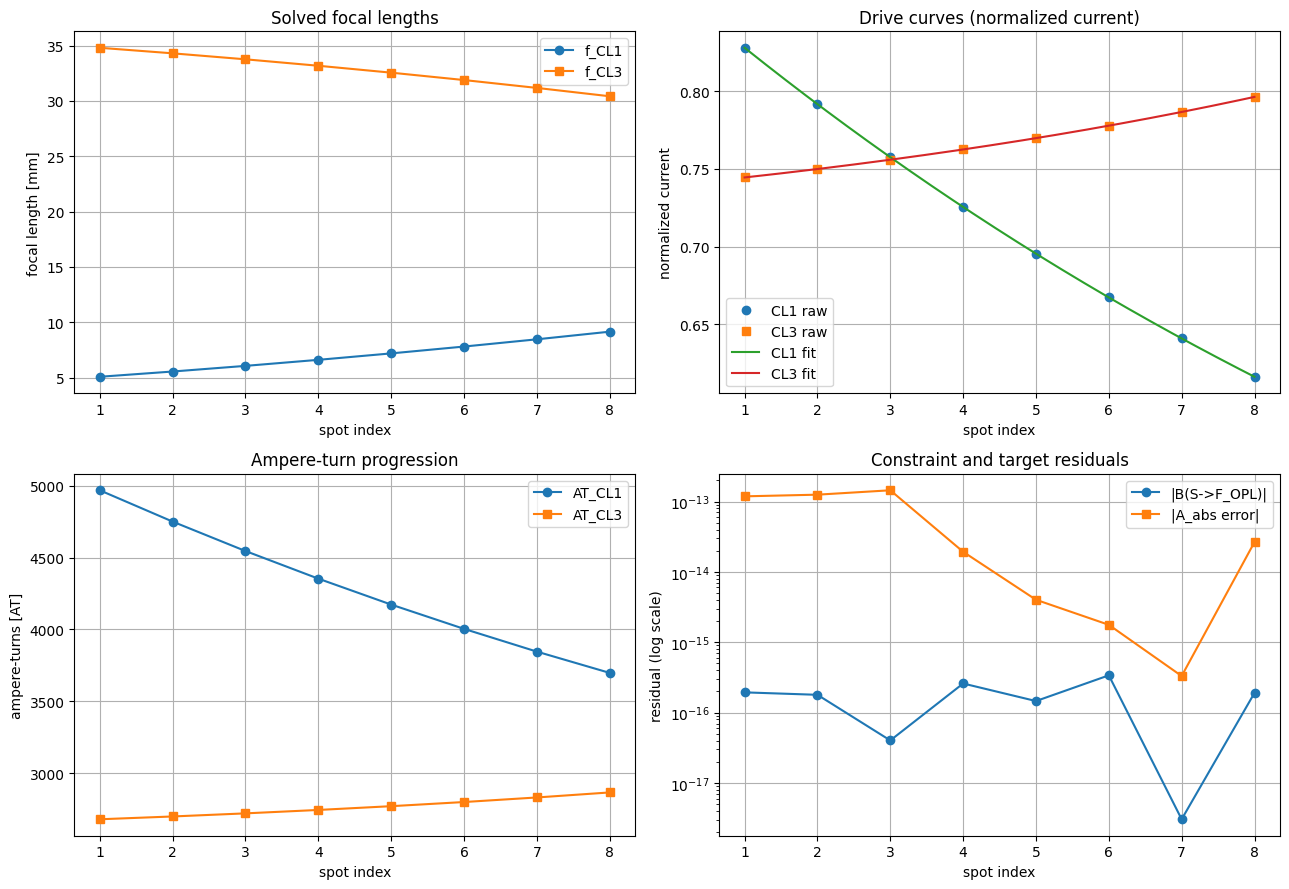

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# focal lengths
axs[0, 0].plot(spot_idx_arr, f1_arr * 1e3, 'o-', label='f_CL1')
axs[0, 0].plot(spot_idx_arr, f3_arr * 1e3, 's-', label='f_CL3')
axs[0, 0].set_xlabel('spot index')
axs[0, 0].set_ylabel('focal length [mm]')
axs[0, 0].set_title('Solved focal lengths')
axs[0, 0].legend()

# currents and smooth fits
axs[0, 1].plot(spot_idx_arr, I1_arr, 'o', label='CL1 raw')
axs[0, 1].plot(spot_idx_arr, I3_arr, 's', label='CL3 raw')
axs[0, 1].plot(spot_dense, i1_dense, '-', label='CL1 fit')
axs[0, 1].plot(spot_dense, i3_dense, '-', label='CL3 fit')
axs[0, 1].set_xlabel('spot index')
axs[0, 1].set_ylabel('normalized current')
axs[0, 1].set_title('Drive curves (normalized current)')
axs[0, 1].legend()

# ampere-turns
axs[1, 0].plot(spot_idx_arr, AT1_arr, 'o-', label='AT_CL1')
axs[1, 0].plot(spot_idx_arr, AT3_arr, 's-', label='AT_CL3')
axs[1, 0].set_xlabel('spot index')
axs[1, 0].set_ylabel('ampere-turns [AT]')
axs[1, 0].set_title('Ampere-turn progression')
axs[1, 0].legend()

# residuals
axs[1, 1].semilogy(spot_idx_arr, np.maximum(np.abs(B_res_arr), 1e-20), 'o-', label='|B(S->F_OPL)|')
axs[1, 1].semilogy(spot_idx_arr, np.maximum(np.abs(A_err_abs_arr), 1e-20), 's-', label='|A_abs error|')
axs[1, 1].set_xlabel('spot index')
axs[1, 1].set_ylabel('residual (log scale)')
axs[1, 1].set_title('Constraint and target residuals')
axs[1, 1].legend()

fig.tight_layout()
plt.show()


### Notes

- This notebook intentionally avoids JSON export.
- Rotation (`theta`) is not used as a target.
- Spot realization is purely optical: hard `B(S->F_OPL)=0` plus a monotonic `|A|` ladder.
